# Google Play reviews pipeline

Notebook completo con flujo principal comparativo y bloque complementario por ventana fija


In [1]:
# Celda 1. Instalar librerías
!pip install google-play-scraper pandas numpy


In [2]:
# Celda 2. Imports
from google_play_scraper import reviews, Sort
import pandas as pd
import numpy as np
from datetime import datetime
import time


In [3]:
# Celda 3. Parámetros generales

LANG = "en"
COUNTRY = "us"

# Fecha final del estudio para el flujo principal.
# Todo lo posterior a este corte se excluye.
WINDOW_END = pd.Timestamp("2026-04-11 23:59:59")

# Ventana fija complementaria.
# Estos parámetros no controlan el flujo principal de comparabilidad.
# Solo sirven para generar los archivos extra por separado al final.
WINDOW_START = pd.Timestamp("2026-03-11 00:00:00")
WINDOW_END_COMPLEMENT = pd.Timestamp("2026-04-11 23:59:59")

# Tamaños de muestra
LICHESS_RAW_TARGET = 1600
FINAL_SAMPLE_SIZE = 1500

# Semilla para el muestreo aleatorio de Chess.com
RANDOM_SEED = 42

# App IDs
LICHESS_APP_ID = "org.lichess.mobileV2"
CHESSCOM_APP_ID = "com.chess"


In [4]:
# Celda 4. Funciones auxiliares

def standardize_google_play_df(df, app_name, lang="en", country="us"):
    """
    Renombra columnas, selecciona variables útiles y añade metadatos.
    """
    if df.empty:
        return df

    rename_map = {
        "reviewId": "review_id",
        "userName": "user_name",
        "content": "review_text",
        "score": "rating",
        "thumbsUpCount": "thumbs_up_count",
        "reviewCreatedVersion": "review_created_version",
        "appVersion": "app_version",
        "at": "review_date",
        "replyContent": "developer_reply",
        "repliedAt": "developer_reply_date",
    }

    df = df.rename(columns=rename_map)

    desired_cols = [
        "review_id",
        "user_name",
        "review_text",
        "rating",
        "thumbs_up_count",
        "review_created_version",
        "app_version",
        "review_date",
        "developer_reply",
        "developer_reply_date",
    ]

    existing_cols = [col for col in desired_cols if col in df.columns]
    df = df[existing_cols].copy()

    df["brand"] = app_name
    df["platform"] = "Google Play"
    df["lang_param"] = lang
    df["country_param"] = country
    df["scraped_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    return df


def save_csv(df, filename):
    """
    Guarda un DataFrame en CSV con codificación utf-8-sig.
    """
    df.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"Archivo guardado: {filename}")


In [5]:
# Celda 5. Limpieza homogénea

def clean_google_play_reviews(df):
    """
    Limpia el dataset bruto de reseñas.

    Pasos:
    1. Convierte rating y thumbs_up_count a numérico
    2. Convierte review_date y developer_reply_date a datetime
    3. Elimina filas con ausencias en variables clave
    4. Conserva solo ratings válidos entre 1 y 5
    5. Elimina textos demasiado cortos (<= 5 caracteres)
    6. Deduplica por review_id
    7. Ordena por review_date descendente
    """
    df = df.copy()

    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    df["thumbs_up_count"] = pd.to_numeric(df["thumbs_up_count"], errors="coerce")

    df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
    df["developer_reply_date"] = pd.to_datetime(df["developer_reply_date"], errors="coerce")

    df = df[
        (df["rating"].notna()) &
        (df["review_text"].notna()) &
        (df["review_date"].notna()) &
        (df["country_param"].notna()) &
        (df["lang_param"].notna()) &
        (df["brand"].notna()) &
        (df["platform"].notna())
    ].copy()

    # Solo ratings válidos de Google Play
    df = df[df["rating"].between(1, 5)].copy()

    # Filtro mínimo de longitud textual para evitar contenido de muy baja información
    df = df[df["review_text"].astype(str).str.len() > 5].copy()

    # review_id es el identificador principal para deduplicación
    df = df.drop_duplicates(subset="review_id")

    # Ordenar de más reciente a más antigua
    df = df.sort_values("review_date", ascending=False).reset_index(drop=True)

    return df


In [6]:
# Celda 6. Extracción principal de Lichess
# Objetivo:
# reunir 1600 reseñas brutas válidas con fecha menor o igual a 11/04/2026

def scrape_lichess_raw_upto_end(app_id, app_name, window_end, target_valid_count=1600, lang="en", country="us"):
    """
    Extrae reseñas recientes de Lichess hasta reunir target_valid_count reseñas
    con fecha menor o igual a window_end.

    Importante:
    - no se para al descargar 1600 reseñas totales
    - se para cuando se han acumulado 1600 reseñas válidas hasta la fecha final del estudio
    """
    valid_reviews = []
    continuation_token = None
    page_counter = 0

    while len(valid_reviews) < target_valid_count:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country=country,
            sort=Sort.NEWEST,
            count=200,
            continuation_token=continuation_token
        )

        if not result:
            print(f"No se devolvieron más reseñas para {app_name}.")
            break

        page_counter += 1

        # Nos quedamos solo con reseñas cuya fecha sea <= 11/04/2026
        filtered_batch = [
            r for r in result
            if r.get("at") is not None and pd.Timestamp(r.get("at")) <= window_end
        ]

        valid_reviews.extend(filtered_batch)

        oldest_valid = min([r.get("at") for r in filtered_batch], default=None)

        print(
            f"{app_name}: página {page_counter}, "
            f"válidas hasta 11/04/2026 acumuladas = {len(valid_reviews)}, "
            f"fecha más antigua válida en esta página = {oldest_valid}"
        )

        if continuation_token is None:
            print(f"Se alcanzó el final de reseñas disponibles para {app_name}.")
            break

        time.sleep(0.5)

    # Conservamos exactamente las 1600 más recientes válidas
    valid_reviews = valid_reviews[:target_valid_count]

    df = pd.DataFrame(valid_reviews)
    df = standardize_google_play_df(df, app_name=app_name, lang=lang, country=country)

    save_csv(df, "lichess_google_play_reviews_us_1600_raw.csv")
    print(f"Total bruto válido {app_name}: {len(df)}")

    return df


In [7]:
# Celda 7. Extraer Lichess bruto hasta 11/04/2026

dfli_raw = scrape_lichess_raw_upto_end(
    app_id=LICHESS_APP_ID,
    app_name="Lichess",
    window_end=WINDOW_END,
    target_valid_count=LICHESS_RAW_TARGET,
    lang=LANG,
    country=COUNTRY
)


Lichess: página 1, válidas hasta 11/04/2026 acumuladas = 178, fecha más antigua válida en esta página = 2026-03-02 17:45:34
Lichess: página 2, válidas hasta 11/04/2026 acumuladas = 378, fecha más antigua válida en esta página = 2026-01-09 01:26:04
Lichess: página 3, válidas hasta 11/04/2026 acumuladas = 578, fecha más antigua válida en esta página = 2025-11-11 05:17:41
Lichess: página 4, válidas hasta 11/04/2026 acumuladas = 778, fecha más antigua válida en esta página = 2025-09-20 17:05:30
Lichess: página 5, válidas hasta 11/04/2026 acumuladas = 978, fecha más antigua válida en esta página = 2025-08-03 19:10:25
Lichess: página 6, válidas hasta 11/04/2026 acumuladas = 1178, fecha más antigua válida en esta página = 2025-06-19 15:57:34
Lichess: página 7, válidas hasta 11/04/2026 acumuladas = 1378, fecha más antigua válida en esta página = 2025-04-22 14:25:22
Lichess: página 8, válidas hasta 11/04/2026 acumuladas = 1578, fecha más antigua válida en esta página = 2025-01-19 10:34:11
Liche

In [8]:
# Celda 8. Limpiar Lichess y construir muestra ancla

dfli_clean = clean_google_play_reviews(dfli_raw)
save_csv(dfli_clean, "lichess_google_play_reviews_us_clean.csv")

print("Lichess limpio:", dfli_clean.shape)

if len(dfli_clean) < FINAL_SAMPLE_SIZE:
    raise ValueError(
        f"Lichess limpio solo tiene {len(dfli_clean)} reseñas y no alcanza las {FINAL_SAMPLE_SIZE} necesarias."
    )

# La muestra ancla son las 1500 reseñas limpias más recientes de Lichess
dfli_anchor = dfli_clean.head(FINAL_SAMPLE_SIZE).copy()
save_csv(dfli_anchor, "lichess_google_play_reviews_us_1500_anchor_final.csv")

anchor_min_date = dfli_anchor["review_date"].min()
anchor_max_date = dfli_anchor["review_date"].max()

print("Muestra ancla Lichess:", dfli_anchor.shape)
print("Fecha mínima ancla:", anchor_min_date)
print("Fecha máxima ancla:", anchor_max_date)


Archivo guardado: lichess_google_play_reviews_us_clean.csv
Lichess limpio: (1538, 15)
Archivo guardado: lichess_google_play_reviews_us_1500_anchor_final.csv
Muestra ancla Lichess: (1500, 15)
Fecha mínima ancla: 2025-01-24 01:24:18
Fecha máxima ancla: 2026-04-11 23:20:04


In [9]:
# Celda 9. Extracción principal de Chess.com
# Objetivo:
# reunir todas las reseñas recientes válidas hasta 11/04/2026
# necesarias para cubrir la fecha mínima de la muestra ancla de Lichess

def scrape_chesscom_until_anchor_date(app_id, app_name, window_end, anchor_min_date, lang="en", country="us"):
    """
    Extrae reseñas recientes de Chess.com con corte superior en 11/04/2026
    y sigue descargando hasta cubrir la fecha mínima de la muestra ancla de Lichess.

    Importante:
    en el flujo principal Chess.com NO se corta en 11/03/2026.
    El corte inferior correcto es anchor_min_date.
    """
    valid_reviews = []
    continuation_token = None
    page_counter = 0
    oldest_valid_seen = None

    while True:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country=country,
            sort=Sort.NEWEST,
            count=200,
            continuation_token=continuation_token
        )

        if not result:
            print(f"No se devolvieron más reseñas para {app_name}.")
            break

        page_counter += 1

        filtered_batch = [
            r for r in result
            if r.get("at") is not None and pd.Timestamp(r.get("at")) <= window_end
        ]

        if filtered_batch:
            valid_reviews.extend(filtered_batch)
            batch_oldest = min(r.get("at") for r in filtered_batch)
            oldest_valid_seen = batch_oldest if oldest_valid_seen is None else min(oldest_valid_seen, batch_oldest)

        print(
            f"{app_name}: página {page_counter}, "
            f"válidas hasta 11/04/2026 acumuladas = {len(valid_reviews)}, "
            f"fecha más antigua válida acumulada = {oldest_valid_seen}"
        )

        # En cuanto cubrimos la fecha mínima de Lichess, paramos.
        if oldest_valid_seen is not None and pd.Timestamp(oldest_valid_seen) <= anchor_min_date:
            print(f"Se ha cubierto la fecha mínima ancla de Lichess para {app_name}.")
            break

        if continuation_token is None:
            print(f"Se alcanzó el final de reseñas disponibles para {app_name}.")
            break

        time.sleep(0.5)

    df = pd.DataFrame(valid_reviews)
    df = standardize_google_play_df(df, app_name=app_name, lang=lang, country=country)

    save_csv(df, "chesscom_google_play_reviews_us_period_raw.csv")
    print(f"Total bruto válido {app_name}: {len(df)}")

    return df


In [10]:
# Celda 10. Extraer Chess.com bruto hasta cubrir la fecha mínima ancla

dfch_raw = scrape_chesscom_until_anchor_date(
    app_id=CHESSCOM_APP_ID,
    app_name="Chess.com",
    window_end=WINDOW_END,
    anchor_min_date=anchor_min_date,
    lang=LANG,
    country=COUNTRY
)


Chess.com: página 1, válidas hasta 11/04/2026 acumuladas = 0, fecha más antigua válida acumulada = None
Chess.com: página 2, válidas hasta 11/04/2026 acumuladas = 0, fecha más antigua válida acumulada = None
Chess.com: página 3, válidas hasta 11/04/2026 acumuladas = 121, fecha más antigua válida acumulada = 2026-04-10 16:53:17
Chess.com: página 4, válidas hasta 11/04/2026 acumuladas = 321, fecha más antigua válida acumulada = 2026-04-08 18:08:27
Chess.com: página 5, válidas hasta 11/04/2026 acumuladas = 521, fecha más antigua válida acumulada = 2026-04-06 15:34:03
Chess.com: página 6, válidas hasta 11/04/2026 acumuladas = 721, fecha más antigua válida acumulada = 2026-04-04 13:34:12
Chess.com: página 7, válidas hasta 11/04/2026 acumuladas = 921, fecha más antigua válida acumulada = 2026-04-02 12:47:14
Chess.com: página 8, válidas hasta 11/04/2026 acumuladas = 1121, fecha más antigua válida acumulada = 2026-03-31 14:46:10
Chess.com: página 9, válidas hasta 11/04/2026 acumuladas = 1321, 

In [11]:
# Celda 11. Limpiar Chess.com y construir pool comparable

dfch_clean = clean_google_play_reviews(dfch_raw)
save_csv(dfch_clean, "chesscom_google_play_reviews_us_clean.csv")

print("Chess.com limpio:", dfch_clean.shape)

# En el flujo principal, Chess.com se recorta usando el periodo exacto de Lichess.
# No se usa 11/03/2026 como corte inferior aquí.
dfch_period = dfch_clean[
    (dfch_clean["review_date"] >= anchor_min_date) &
    (dfch_clean["review_date"] <= anchor_max_date)
].copy()

print("Chess.com dentro del periodo comparable:", dfch_period.shape)


Archivo guardado: chesscom_google_play_reviews_us_clean.csv
Chess.com limpio: (34797, 15)
Chess.com dentro del periodo comparable: (34690, 15)


In [12]:
# Celda 12. Estratos semanales

def add_week_stratum(df, date_col="review_date"):
    """
    Crea un estrato temporal semanal con semana natural e inicio en lunes.
    """
    df = df.copy()
    df["week_start"] = df[date_col].dt.to_period("W-MON").apply(lambda r: r.start_time)
    return df

dfli_anchor = add_week_stratum(dfli_anchor)
dfch_period = add_week_stratum(dfch_period)


In [13]:
# Celda 13. Distribución semanal de Lichess

li_week_dist = (
    dfli_anchor.groupby("week_start")
    .size()
    .reset_index(name="n_lichess")
    .sort_values("week_start")
    .reset_index(drop=True)
)

li_week_dist["share_lichess"] = li_week_dist["n_lichess"] / li_week_dist["n_lichess"].sum()

li_week_dist


,week_start,n_lichess,share_lichess
0,2025-01-21,13,0.008667
1,2025-01-28,18,0.012000
2,2025-02-04,11,0.007333
3,2025-02-11,14,0.009333
4,2025-02-18,11,0.007333
...,...,...,...
59,2026-03-10,22,0.014667
60,2026-03-17,33,0.022000
61,2026-03-24,38,0.025333
62,2026-03-31,31,0.020667


In [14]:
# Celda 14. Muestreo aleatorio estratificado de Chess.com por semana

def stratified_sample_like_anchor(df_source, anchor_dist, target_total, week_col="week_start", random_seed=42):
    """
    
    1. En cada semana intentamos tomar el mismo número que en Lichess
    2. Si Chess.com tiene menos en alguna semana, tomamos todas las disponibles
    3. Si aún faltan reseñas para llegar a 1500, completamos desde el resto
       del pool del mismo periodo comparable
    """
    df_source = df_source.copy()

    source_week_counts = (
        df_source.groupby(week_col)
        .size()
        .reset_index(name="n_source_available")
    )

    plan = anchor_dist.merge(source_week_counts, on=week_col, how="left")
    plan["n_source_available"] = plan["n_source_available"].fillna(0).astype(int)

    plan["n_take_initial"] = plan[["n_lichess", "n_source_available"]].min(axis=1)

    sampled_parts = []

    for _, row in plan.iterrows():
        week = row[week_col]
        n_take = int(row["n_take_initial"])

        week_df = df_source[df_source[week_col] == week]

        if n_take > 0:
            week_sample = week_df.sample(n=n_take, random_state=random_seed)
            sampled_parts.append(week_sample)

    sampled_df = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else pd.DataFrame(columns=df_source.columns)

    remaining_needed = target_total - len(sampled_df)

    if remaining_needed > 0:
        remaining_pool = df_source.loc[~df_source["review_id"].isin(sampled_df["review_id"])].copy()

        if len(remaining_pool) > 0:
            n_extra = min(remaining_needed, len(remaining_pool))
            extra_sample = remaining_pool.sample(n=n_extra, random_state=random_seed)
            sampled_df = pd.concat([sampled_df, extra_sample], ignore_index=True)

    if len(sampled_df) > target_total:
        sampled_df = sampled_df.sample(n=target_total, random_state=random_seed)

    sampled_df = sampled_df.sort_values("review_date", ascending=False).reset_index(drop=True)

    return sampled_df, plan


In [15]:
# Celda 15. Construir muestra final comparable de Chess.com

dfch_final, chess_sampling_plan = stratified_sample_like_anchor(
    df_source=dfch_period,
    anchor_dist=li_week_dist,
    target_total=FINAL_SAMPLE_SIZE,
    week_col="week_start",
    random_seed=RANDOM_SEED
)

save_csv(dfch_final, "chesscom_google_play_reviews_us_1500_comparable_final.csv")
save_csv(chess_sampling_plan, "chesscom_sampling_plan_by_week.csv")

print("Lichess final:", len(dfli_anchor))
print("Chess.com final:", len(dfch_final))


Archivo guardado: chesscom_google_play_reviews_us_1500_comparable_final.csv
Archivo guardado: chesscom_sampling_plan_by_week.csv
Lichess final: 1500
Chess.com final: 1500


In [16]:
# Celda 16. Comparación semanal y dataset final comparable

li_final_week = (
    dfli_anchor.groupby("week_start")
    .size()
    .reset_index(name="n_lichess_final")
)

ch_final_week = (
    dfch_final.groupby("week_start")
    .size()
    .reset_index(name="n_chess_final")
)

week_compare = li_final_week.merge(ch_final_week, on="week_start", how="outer").fillna(0)
week_compare = week_compare.sort_values("week_start").reset_index(drop=True)

save_csv(week_compare, "weekly_distribution_comparison_lichess_vs_chesscom.csv")

df_final = pd.concat([dfli_anchor, dfch_final], ignore_index=True)
save_csv(df_final, "google_play_reviews_final_comparable_dataset.csv")

print("Dataset final comparable:", df_final.shape)
print(df_final["brand"].value_counts())


Archivo guardado: weekly_distribution_comparison_lichess_vs_chesscom.csv
Archivo guardado: google_play_reviews_final_comparable_dataset.csv
Dataset final comparable: (3000, 16)
brand
Lichess      1500
Chess.com    1500
Name: count, dtype: int64


In [17]:
# Celda 17. Bloque complementario
# Aquí sí se filtra cada aplicación por separado entre 11/03/2026 y 11/04/2026.
# Este bloque no altera el flujo principal.

dfli_clean["review_date"] = pd.to_datetime(dfli_clean["review_date"], errors="coerce")
dfch_clean["review_date"] = pd.to_datetime(dfch_clean["review_date"], errors="coerce")

dfli_window_complement = dfli_clean[
    (dfli_clean["review_date"] >= WINDOW_START) &
    (dfli_clean["review_date"] <= WINDOW_END_COMPLEMENT)
].copy()

dfch_window_complement = dfch_clean[
    (dfch_clean["review_date"] >= WINDOW_START) &
    (dfch_clean["review_date"] <= WINDOW_END_COMPLEMENT)
].copy()

save_csv(
    dfli_window_complement,
    "lichess_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv"
)

save_csv(
    dfch_window_complement,
    "chesscom_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv"
)

print("Lichess 11/03-11/04:", dfli_window_complement.shape)
print("Chess.com 11/03-11/04:", dfch_window_complement.shape)


Archivo guardado: lichess_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv
Archivo guardado: chesscom_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv
Lichess 11/03-11/04: (142, 15)
Chess.com 11/03-11/04: (2743, 15)


In [18]:
# Celda 18. Resúmenes rápidos

summary_main = df_final.groupby("brand").agg(
    n_reviews=("review_id", "count"),
    min_date=("review_date", "min"),
    max_date=("review_date", "max"),
    avg_rating=("rating", "mean"),
    median_rating=("rating", "median"),
    avg_thumbs_up=("thumbs_up_count", "mean")
).reset_index()

print("Resumen flujo principal:")
display(summary_main)

summary_complement = pd.concat([dfli_window_complement, dfch_window_complement], ignore_index=True).groupby("brand").agg(
    n_reviews=("review_id", "count"),
    min_date=("review_date", "min"),
    max_date=("review_date", "max"),
    avg_rating=("rating", "mean"),
    median_rating=("rating", "median"),
    avg_thumbs_up=("thumbs_up_count", "mean")
).reset_index()

print("Resumen bloque complementario:")
display(summary_complement)


Resumen flujo principal:


,brand,n_reviews,min_date,max_date,avg_rating,median_rating,avg_thumbs_up
0,Chess.com,1500,2025-01-24 06:40:22,2026-04-11 20:28:30,4.219333,5.0,0.397333
1,Lichess,1500,2025-01-24 01:24:18,2026-04-11 23:20:04,3.310667,4.0,3.004000


Resumen bloque complementario:


,brand,n_reviews,min_date,max_date,avg_rating,median_rating,avg_thumbs_up
0,Chess.com,2743,2026-03-11 00:25:24,2026-04-11 23:37:13,4.044841,5.0,0.339774
1,Lichess,142,2026-03-11 10:20:43,2026-04-11 23:20:04,3.436620,4.0,1.330986


In [19]:
# Celda 19. Lista de archivos generados

generated_files = [
    "lichess_google_play_reviews_us_1600_raw.csv",
    "lichess_google_play_reviews_us_clean.csv",
    "lichess_google_play_reviews_us_1500_anchor_final.csv",
    "chesscom_google_play_reviews_us_period_raw.csv",
    "chesscom_google_play_reviews_us_clean.csv",
    "chesscom_google_play_reviews_us_1500_comparable_final.csv",
    "chesscom_sampling_plan_by_week.csv",
    "weekly_distribution_comparison_lichess_vs_chesscom.csv",
    "google_play_reviews_final_comparable_dataset.csv",
    "lichess_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv",
    "chesscom_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv",
]

for f in generated_files:
    print(f)


lichess_google_play_reviews_us_1600_raw.csv
lichess_google_play_reviews_us_clean.csv
lichess_google_play_reviews_us_1500_anchor_final.csv
chesscom_google_play_reviews_us_period_raw.csv
chesscom_google_play_reviews_us_clean.csv
chesscom_google_play_reviews_us_1500_comparable_final.csv
chesscom_sampling_plan_by_week.csv
weekly_distribution_comparison_lichess_vs_chesscom.csv
google_play_reviews_final_comparable_dataset.csv
lichess_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv
chesscom_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv


# Bloque de temas

Extensión del código original para codificación por temas de reseñas de Google Play.


In [20]:
# =========================
# BLOQUE TEMAS
# =========================

from collections import OrderedDict
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "df_final" not in globals():
    df_final = pd.read_csv("google_play_reviews_final_comparable_dataset.csv")

if "dfli_window_complement" not in globals():
    dfli_window_complement = pd.read_csv("lichess_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv")

if "dfch_window_complement" not in globals():
    dfch_window_complement = pd.read_csv("chesscom_google_play_reviews_2026-03-11_to_2026-04-11_clean.csv")

# Copias de trabajo para no editar los objetos base
df_comparable_base = df_final.copy()
df_fixed_window_base = pd.concat(
    [dfli_window_complement.copy(), dfch_window_complement.copy()],
    ignore_index=True
)

for _df in [df_comparable_base, df_fixed_window_base]:
    _df["review_text"] = _df["review_text"].fillna("").astype(str)
    _df["rating"] = pd.to_numeric(_df["rating"], errors="coerce")
    if "thumbs_up_count" in _df.columns:
        _df["thumbs_up_count"] = pd.to_numeric(_df["thumbs_up_count"], errors="coerce")
    else:
        _df["thumbs_up_count"] = np.nan
    _df["review_date"] = pd.to_datetime(_df["review_date"], errors="coerce")

print("Dataset comparable reutilizado:", df_comparable_base.shape)
print(df_comparable_base["brand"].value_counts(dropna=False))
print()
print("Dataset ventana fija reutilizado:", df_fixed_window_base.shape)
print(df_fixed_window_base["brand"].value_counts(dropna=False))


# -------------------------


Dataset comparable reutilizado: (3000, 16)
brand
Lichess      1500
Chess.com    1500
Name: count, dtype: int64

Dataset ventana fija reutilizado: (2885, 15)
brand
Chess.com    2743
Lichess       142
Name: count, dtype: int64


In [21]:
# 2. Codebook por temas 
# -------------------------

# Nota importante:
# La codificación es multietiqueta.
# Una misma reseña puede activar más de un tema.
# Por eso, los porcentajes por tema dentro de una plataforma no tienen por qué sumar 100%.

theme_codebook = OrderedDict({
    "analysis_tools": {
        "theme_es": "Análisis y herramientas",
        "description_es": "Referencias a análisis postpartida, motor, evaluación, estudio y herramientas analíticas",
        "patterns": [
            r"\banalysis\b", r"\banalyze\b", r"\banalyse\b", r"\banalysing\b",
            r"\bengine\b", r"\bstockfish\b", r"\beval\b", r"\bevaluation\b",
            r"\bgame review\b", r"\banalysis board\b", r"\bpgn\b", r"\bimport games?\b"
        ]
    },
    "puzzles_learning": {
        "theme_es": "Puzles y aprendizaje",
        "description_es": "Puzles, lecciones, entrenamiento, estudio y aprendizaje",
        "patterns": [
            r"\bpuzzle\b", r"\bpuzzles\b", r"\blesson\b", r"\blessons\b",
            r"\blearn\b", r"\blearning\b", r"\btraining\b", r"\bpractice\b",
            r"\bstudy\b", r"\bstudying\b", r"\bopening\b", r"\bopenings\b",
            r"\bdrills?\b", r"\bcoach\b"
        ]
    },
    "gameplay_matchmaking": {
        "theme_es": "Jugabilidad y emparejamiento",
        "description_es": "Jugabilidad, ritmo de partida, rating, bots y emparejamiento",
        "patterns": [
            r"\bmatchmaking\b", r"\bopponent\b", r"\bopponents\b", r"\bpairing\b",
            r"\brated\b", r"\brating\b", r"\belo\b", r"\bblitz\b", r"\bbullet\b",
            r"\brapid\b", r"\bclassical\b", r"\bbot\b", r"\bbots\b",
            r"\btime control\b", r"\bpair(ed|ing)?\b", r"\bgameplay\b"
        ]
    },
    "performance_stability": {
        "theme_es": "Rendimiento, estabilidad y fallos",
        "description_es": "Lag, bugs, crashes, problemas de carga y estabilidad",
        "patterns": [
            r"\bcrash\b", r"\bcrashes\b", r"\bcrashed\b", r"\bbug\b", r"\bbugs\b",
            r"\blag\b", r"\blaggy\b", r"\bslow\b", r"\bfreeze\b", r"\bfreezes\b",
            r"\bglitch\b", r"\bglitches\b", r"\bloading\b", r"\bdisconnect\b",
            r"\bconnection\b", r"\bserver\b", r"\bnot working\b", r"\bbroken\b"
        ]
    },
    "interface_usability": {
        "theme_es": "Interfaz y usabilidad",
        "description_es": "Diseño, interfaz, navegación, facilidad de uso y experiencia general de uso",
        "patterns": [
            r"\bui\b", r"\bux\b", r"\binterface\b", r"\bdesign\b", r"\blayout\b",
            r"\bnavigation\b", r"\buser friendly\b", r"\beasy to use\b",
            r"\bhard to use\b", r"\bconfusing\b", r"\bclean\b",
            r"\bintuitive\b", r"\bmenu\b", r"\bmenus\b"
        ]
    },
    "account_access": {
        "theme_es": "Cuenta y acceso",
        "description_es": "Login, email, contraseña, verificación y acceso a la cuenta",
        "patterns": [
            r"\blogin\b", r"\blog in\b", r"\bsign in\b", r"\baccount\b",
            r"\bpassword\b", r"\bemail\b", r"\bverification\b", r"\bverify\b",
            r"\baccess\b", r"\bcredentials?\b", r"\busername\b"
        ]
    },
    "fair_play_moderation": {
        "theme_es": "Fair play, trampas y moderación",
        "description_es": "Cheating, bans, reports, moderación y fair play",
        "patterns": [
            r"\bcheat\b", r"\bcheats\b", r"\bcheater\b", r"\bcheaters\b",
            r"\bcheating\b", r"\bfair play\b", r"\breport\b", r"\breported\b",
            r"\bban\b", r"\bbanned\b", r"\bmoderation\b", r"\bmoderator\b"
        ]
    },
    "ads_pricing_premium": {
        "theme_es": "Anuncios, precio y premium",
        "description_es": "Ads, premium, suscripción, paywall y precio",
        "patterns": [
            r"\bad\b", r"\bads\b", r"\badvert\b", r"\badvertisement\b",
            r"\bpremium\b", r"\bsubscription\b", r"\bsubscribe\b", r"\bpaywall\b",
            r"\bpaid\b", r"\bprice\b", r"\bpricing\b", r"\bmembership\b",
            r"\bdiamond\b", r"\bgold\b", r"\bplatinum\b"
        ]
    },
    "community_tournaments_social": {
        "theme_es": "Comunidad, torneos y social",
        "description_es": "Torneos, clubes, comunidad, chat, amigos y equipos",
        "patterns": [
            r"\btournament\b", r"\btournaments\b", r"\barena\b", r"\bclub\b",
            r"\bclubs\b", r"\bcommunity\b", r"\bchat\b", r"\bfriends?\b",
            r"\bteam\b", r"\bteams\b", r"\bsocial\b"
        ]
    },
    "updates_version_changes": {
        "theme_es": "Actualizaciones y cambios de versión",
        "description_es": "Updates, cambios de versión, legacy y upgrades",
        "patterns": [
            r"\bupdate\b", r"\bupdates\b", r"\bupdated\b", r"\bupdating\b",
            r"\bversion\b", r"\blegacy\b", r"\bbeta\b", r"\bupgrade\b",
            r"\bupgraded\b", r"\bnew version\b", r"\bold version\b"
        ]
    },
    "developer_support": {
        "theme_es": "Soporte y respuesta del desarrollador",
        "description_es": "Soporte, atención al usuario y respuesta del desarrollador",
        "patterns": [
            r"\bsupport\b", r"\bdeveloper response\b", r"\bdevelopers?\b",
            r"\bhelp desk\b", r"\bcustomer service\b", r"\bresponse\b"
        ]
    },
    "overall_appraisal": {
        "theme_es": "Valoración general",
        "description_es": "Valoraciones generales no funcionales sobre la app",
        "patterns": [
            r"\bbest app\b", r"\bgreat app\b", r"\bgood app\b", r"\bawesome app\b",
            r"\blove this app\b", r"\bexcellent app\b", r"\bterrible app\b",
            r"\bbad app\b", r"\bworst app\b", r"\bvery good\b", r"\bvery bad\b"
        ]
    }
})

theme_codebook_df = pd.DataFrame([
    {
        "theme": theme,
        "theme_es": meta["theme_es"],
        "description_es": meta["description_es"],
        "patterns_joined": " | ".join(meta["patterns"])
    }
    for theme, meta in theme_codebook.items()
])

theme_codebook_df.to_csv(
    "google_play_reviews_theme_codebook.csv",
    index=False,
    encoding="utf-8-sig"
)

compiled_patterns = {
    theme: [re.compile(pattern, flags=re.IGNORECASE) for pattern in meta["patterns"]]
    for theme, meta in theme_codebook.items()
}


# -------------------------


In [22]:
# 3. Función de codificación multietiqueta
# -------------------------

theme_priority = [
    "performance_stability",
    "account_access",
    "fair_play_moderation",
    "ads_pricing_premium",
    "analysis_tools",
    "puzzles_learning",
    "gameplay_matchmaking",
    "interface_usability",
    "community_tournaments_social",
    "updates_version_changes",
    "developer_support",
    "overall_appraisal"
]

def code_review_text(text):
    text = "" if pd.isna(text) else str(text)

    matched_themes = []
    trigger_map = {}

    for theme, regex_list in compiled_patterns.items():
        hits = []
        for regex in regex_list:
            matches = regex.findall(text)
            if matches:
                if isinstance(matches, list):
                    for match in matches:
                        if isinstance(match, tuple):
                            match = " ".join([m for m in match if m])
                        hits.append(str(match))
        if hits:
            matched_themes.append(theme)
            unique_hits = []
            seen = set()
            for hit in hits:
                key = hit.lower().strip()
                if key not in seen:
                    seen.add(key)
                    unique_hits.append(hit)
            trigger_map[theme] = unique_hits[:5]

    if matched_themes:
        ordered = [theme for theme in theme_priority if theme in matched_themes]
        primary_theme = ordered[0] if ordered else matched_themes[0]
    else:
        primary_theme = np.nan

    return pd.Series({
        "matched_themes": matched_themes,
        "matched_themes_json": json.dumps(matched_themes, ensure_ascii=False),
        "n_themes_detected": len(matched_themes),
        "primary_theme": primary_theme,
        "primary_theme_es": theme_codebook.get(primary_theme, {}).get("theme_es", np.nan) if pd.notna(primary_theme) else np.nan,
        "primary_trigger": trigger_map.get(primary_theme, [np.nan])[0] if pd.notna(primary_theme) and primary_theme in trigger_map else np.nan,
        "theme_triggers_json": json.dumps(trigger_map, ensure_ascii=False)
    })


def apply_thematic_coding(df, dataset_type):
    df = df.copy()
    coded = df["review_text"].apply(code_review_text)
    df = pd.concat([df, coded], axis=1)

    for theme in theme_codebook.keys():
        df[f"theme__{theme}"] = df["matched_themes"].apply(lambda themes: int(theme in themes))

    df["is_coded"] = (df["n_themes_detected"] > 0).astype(int)
    df["is_multilabel"] = (df["n_themes_detected"] > 1).astype(int)
    df["dataset_type"] = dataset_type

    return df


df_comparable_coded = apply_thematic_coding(
    df_comparable_base,
    dataset_type="comparable_final_3000"
)

df_fixed_window_coded = apply_thematic_coding(
    df_fixed_window_base,
    dataset_type="fixed_window_2026-03-11_to_2026-04-11"
)

df_comparable_coded.to_csv(
    "google_play_reviews_comparable_dataset_thematic_coded.csv",
    index=False,
    encoding="utf-8-sig"
)

df_fixed_window_coded.to_csv(
    "google_play_reviews_fixed_window_2026-03-11_to_2026-04-11_thematic_coded.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Comparable codificado:", df_comparable_coded.shape)
print("Ventana fija codificada:", df_fixed_window_coded.shape)


# -------------------------


Comparable codificado: (3000, 38)
Ventana fija codificada: (2885, 37)


In [23]:
# 4. Cobertura de codificación
# -------------------------

def build_coverage_summary(df):
    rows = []
    for brand in sorted(df["brand"].dropna().unique()):
        subset = df[df["brand"] == brand].copy()
        rows.append({
            "dataset_type": subset["dataset_type"].iloc[0],
            "brand": brand,
            "n_reviews": len(subset),
            "n_coded": int((subset["is_coded"] == 1).sum()),
            "pct_coded": float((subset["is_coded"] == 1).mean()),
            "n_uncoded": int((subset["is_coded"] == 0).sum()),
            "pct_uncoded": float((subset["is_coded"] == 0).mean()),
            "n_monolabel": int((subset["n_themes_detected"] == 1).sum()),
            "pct_monolabel": float((subset["n_themes_detected"] == 1).mean()),
            "n_multilabel": int((subset["n_themes_detected"] > 1).sum()),
            "pct_multilabel": float((subset["n_themes_detected"] > 1).mean())
        })
    return pd.DataFrame(rows)

coverage_summary = pd.concat(
    [
        build_coverage_summary(df_comparable_coded),
        build_coverage_summary(df_fixed_window_coded)
    ],
    ignore_index=True
)

coverage_summary.to_csv(
    "google_play_reviews_theme_coverage_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

display(coverage_summary)


# -------------------------


,dataset_type,brand,n_reviews,n_coded,pct_coded,n_uncoded,pct_uncoded,n_monolabel,pct_monolabel,n_multilabel,pct_multilabel
0,comparable_final_3000,Chess.com,1500,544,0.362667,956,0.637333,390,0.260000,154,0.102667
1,comparable_final_3000,Lichess,1500,926,0.617333,574,0.382667,572,0.381333,354,0.236000
2,fixed_window_2026-03-11_to_2026-04-11,Chess.com,2743,1116,0.406854,1627,0.593146,731,0.266497,385,0.140357
3,fixed_window_2026-03-11_to_2026-04-11,Lichess,142,91,0.640845,51,0.359155,55,0.387324,36,0.253521


In [24]:
# 5. Resumen por plataforma y tema
# -------------------------

def build_theme_summary(df):
    exploded = df.explode("matched_themes").copy()
    exploded = exploded[exploded["matched_themes"].notna()].copy()
    exploded = exploded.rename(columns={"matched_themes": "theme"})

    exploded["theme_es"] = exploded["theme"].map(
        {theme: meta["theme_es"] for theme, meta in theme_codebook.items()}
    )

    summary = (
        exploded
        .groupby(["dataset_type", "brand", "theme", "theme_es"], dropna=False)
        .agg(
            n_reviews=("review_text", "size"),
            average_rating=("rating", "mean"),
            median_rating=("rating", "median"),
            pct_1_2_star=("rating", lambda s: s.isin([1, 2]).mean()),
            pct_4_5_star=("rating", lambda s: s.isin([4, 5]).mean()),
            helpful_votes_mean=("thumbs_up_count", "mean")
        )
        .reset_index()
    )

    totals = (
        df.groupby(["dataset_type", "brand"], dropna=False)
        .size()
        .reset_index(name="n_reviews_total_brand")
    )

    summary = summary.merge(totals, on=["dataset_type", "brand"], how="left")
    summary["share_of_reviews"] = summary["n_reviews"] / summary["n_reviews_total_brand"]

    return summary

theme_summary_df = pd.concat(
    [
        build_theme_summary(df_comparable_coded),
        build_theme_summary(df_fixed_window_coded)
    ],
    ignore_index=True
)

theme_summary_df.to_csv(
    "google_play_reviews_theme_summary_by_brand.csv",
    index=False,
    encoding="utf-8-sig"
)

display(theme_summary_df.head(20))


# -------------------------


,dataset_type,brand,theme,theme_es,n_reviews,average_rating,median_rating,pct_1_2_star,pct_4_5_star,helpful_votes_mean,n_reviews_total_brand,share_of_reviews
0,comparable_final_3000,Chess.com,account_access,Cuenta y acceso,33,2.030303,1.0,0.696970,0.242424,0.545455,1500,0.022000
1,comparable_final_3000,Chess.com,ads_pricing_premium,"Anuncios, precio y premium",71,3.309859,4.0,0.352113,0.591549,4.211268,1500,0.047333
2,comparable_final_3000,Chess.com,analysis_tools,Análisis y herramientas,30,3.766667,4.0,0.200000,0.700000,2.766667,1500,0.020000
3,comparable_final_3000,Chess.com,community_tournaments_social,"Comunidad, torneos y social",49,3.918367,5.0,0.204082,0.734694,0.387755,1500,0.032667
4,comparable_final_3000,Chess.com,developer_support,Soporte y respuesta del desarrollador,18,2.333333,1.5,0.666667,0.277778,2.611111,1500,0.012000
5,comparable_final_3000,Chess.com,fair_play_moderation,"Fair play, trampas y moderación",36,1.500000,1.0,0.888889,0.083333,1.166667,1500,0.024000
6,comparable_final_3000,Chess.com,gameplay_matchmaking,Jugabilidad y emparejamiento,96,3.208333,4.0,0.395833,0.531250,2.552083,1500,0.064000
7,comparable_final_3000,Chess.com,interface_usability,Interfaz y usabilidad,27,3.629630,4.0,0.259259,0.740741,0.185185,1500,0.018000
8,comparable_final_3000,Chess.com,overall_appraisal,Valoración general,181,4.558011,5.0,0.066298,0.922652,0.287293,1500,0.120667
9,comparable_final_3000,Chess.com,performance_stability,"Rendimiento, estabilidad y fallos",46,2.043478,1.0,0.673913,0.239130,0.630435,1500,0.030667


In [25]:
# 6. Comparativa directa Chess.com vs Lichess por tema
# -------------------------

def build_theme_comparison(summary_df):
    comparison_parts = []

    for dataset_type in sorted(summary_df["dataset_type"].unique()):
        sub = summary_df[summary_df["dataset_type"] == dataset_type].copy()

        pivot = sub.pivot_table(
            index=["theme", "theme_es"],
            columns="brand",
            values=["n_reviews", "share_of_reviews", "average_rating"],
            aggfunc="first"
        )

        pivot.columns = [
            f"{metric}_{brand.lower().replace('.', '').replace(' ', '_')}"
            for metric, brand in pivot.columns
        ]
        pivot = pivot.reset_index()

        if "share_of_reviews_chesscom" in pivot.columns and "share_of_reviews_lichess" in pivot.columns:
            pivot["share_diff_chesscom_minus_lichess"] = (
                pivot["share_of_reviews_chesscom"] - pivot["share_of_reviews_lichess"]
            )
            pivot["overrepresentation_ratio_chesscom_vs_lichess"] = np.where(
                pivot["share_of_reviews_lichess"] > 0,
                pivot["share_of_reviews_chesscom"] / pivot["share_of_reviews_lichess"],
                np.nan
            )

        if "average_rating_chesscom" in pivot.columns and "average_rating_lichess" in pivot.columns:
            pivot["rating_diff_chesscom_minus_lichess"] = (
                pivot["average_rating_chesscom"] - pivot["average_rating_lichess"]
            )

        pivot["dataset_type"] = dataset_type
        comparison_parts.append(pivot)

    return pd.concat(comparison_parts, ignore_index=True)

theme_comparison_df = build_theme_comparison(theme_summary_df)

theme_comparison_df.to_csv(
    "google_play_reviews_theme_comparison_chesscom_vs_lichess.csv",
    index=False,
    encoding="utf-8-sig"
)

display(theme_comparison_df.head(20))


# -------------------------


,theme,theme_es,average_rating_chesscom,average_rating_lichess,n_reviews_chesscom,n_reviews_lichess,share_of_reviews_chesscom,share_of_reviews_lichess,share_diff_chesscom_minus_lichess,overrepresentation_ratio_chesscom_vs_lichess,rating_diff_chesscom_minus_lichess,dataset_type
0,account_access,Cuenta y acceso,2.030303,1.913043,33.0,92.0,0.022000,0.061333,-0.039333,0.358696,0.117260,comparable_final_3000
1,ads_pricing_premium,"Anuncios, precio y premium",3.309859,4.711538,71.0,52.0,0.047333,0.034667,0.012667,1.365385,-1.401679,comparable_final_3000
2,analysis_tools,Análisis y herramientas,3.766667,3.592105,30.0,152.0,0.020000,0.101333,-0.081333,0.197368,0.174561,comparable_final_3000
3,community_tournaments_social,"Comunidad, torneos y social",3.918367,3.171429,49.0,105.0,0.032667,0.070000,-0.037333,0.466667,0.746939,comparable_final_3000
4,developer_support,Soporte y respuesta del desarrollador,2.333333,2.882353,18.0,17.0,0.012000,0.011333,0.000667,1.058824,-0.549020,comparable_final_3000
5,fair_play_moderation,"Fair play, trampas y moderación",1.500000,1.460000,36.0,50.0,0.024000,0.033333,-0.009333,0.720000,0.040000,comparable_final_3000
6,gameplay_matchmaking,Jugabilidad y emparejamiento,3.208333,2.591195,96.0,159.0,0.064000,0.106000,-0.042000,0.603774,0.617138,comparable_final_3000
7,interface_usability,Interfaz y usabilidad,3.629630,3.118343,27.0,169.0,0.018000,0.112667,-0.094667,0.159763,0.511286,comparable_final_3000
8,overall_appraisal,Valoración general,4.558011,4.127389,181.0,157.0,0.120667,0.104667,0.016000,1.152866,0.430623,comparable_final_3000
9,performance_stability,"Rendimiento, estabilidad y fallos",2.043478,2.009804,46.0,102.0,0.030667,0.068000,-0.037333,0.450980,0.033674,comparable_final_3000


In [26]:
# 7. Tabla final para redactar
# -------------------------

table_for_writing = theme_summary_df[
    theme_summary_df["dataset_type"] == "comparable_final_3000"
].copy()

table_for_writing = table_for_writing[
    [
        "brand",
        "theme",
        "theme_es",
        "n_reviews",
        "share_of_reviews",
        "average_rating",
        "pct_1_2_star",
        "pct_4_5_star",
        "helpful_votes_mean"
    ]
].copy()

table_for_writing = table_for_writing.rename(columns={
    "brand": "Plataforma",
    "theme": "theme_code",
    "theme_es": "Tema",
    "n_reviews": "n_reseñas",
    "share_of_reviews": "pct_dentro_plataforma",
    "average_rating": "rating_medio",
    "pct_1_2_star": "pct_1_2_estrellas",
    "pct_4_5_star": "pct_4_5_estrellas",
    "helpful_votes_mean": "helpful_votes_media"
})

table_for_writing["pct_dentro_plataforma"] = table_for_writing["pct_dentro_plataforma"] * 100
table_for_writing["pct_1_2_estrellas"] = table_for_writing["pct_1_2_estrellas"] * 100
table_for_writing["pct_4_5_estrellas"] = table_for_writing["pct_4_5_estrellas"] * 100

table_for_writing = table_for_writing.sort_values(
    ["Plataforma", "pct_dentro_plataforma", "n_reseñas"],
    ascending=[True, False, False]
)

table_for_writing.to_csv(
    "google_play_reviews_theme_table_for_writing_comparable.csv",
    index=False,
    encoding="utf-8-sig"
)

display(table_for_writing.head(20))


# -------------------------


,Plataforma,theme_code,Tema,n_reseñas,pct_dentro_plataforma,rating_medio,pct_1_2_estrellas,pct_4_5_estrellas,helpful_votes_media
8,Chess.com,overall_appraisal,Valoración general,181,12.066667,4.558011,6.629834,92.265193,0.287293
10,Chess.com,puzzles_learning,Puzles y aprendizaje,152,10.133333,4.197368,13.815789,80.921053,2.052632
6,Chess.com,gameplay_matchmaking,Jugabilidad y emparejamiento,96,6.400000,3.208333,39.583333,53.125000,2.552083
1,Chess.com,ads_pricing_premium,"Anuncios, precio y premium",71,4.733333,3.309859,35.211268,59.154930,4.211268
3,Chess.com,community_tournaments_social,"Comunidad, torneos y social",49,3.266667,3.918367,20.408163,73.469388,0.387755
9,Chess.com,performance_stability,"Rendimiento, estabilidad y fallos",46,3.066667,2.043478,67.391304,23.913043,0.630435
5,Chess.com,fair_play_moderation,"Fair play, trampas y moderación",36,2.400000,1.500000,88.888889,8.333333,1.166667
0,Chess.com,account_access,Cuenta y acceso,33,2.200000,2.030303,69.696970,24.242424,0.545455
2,Chess.com,analysis_tools,Análisis y herramientas,30,2.000000,3.766667,20.000000,70.000000,2.766667
7,Chess.com,interface_usability,Interfaz y usabilidad,27,1.800000,3.629630,25.925926,74.074074,0.185185


In [27]:
# 8. Versiones limpias para el TFG
# -------------------------

excluded_general_themes = ["overall_appraisal"]


theme_summary_df_clean = theme_summary_df[
    ~theme_summary_df["theme"].isin(excluded_general_themes + optional_excluded_themes)
].copy()

theme_comparison_df_clean = theme_comparison_df[
    ~theme_comparison_df["theme"].isin(excluded_general_themes + optional_excluded_themes)
].copy()

theme_summary_df_clean.to_csv(
    "google_play_reviews_theme_summary_by_brand_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

theme_comparison_df_clean.to_csv(
    "google_play_reviews_theme_comparison_chesscom_vs_lichess_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

table_for_writing_clean = table_for_writing[
    ~table_for_writing["theme_code"].isin(excluded_general_themes + optional_excluded_themes)
].copy()

table_for_writing_clean.to_csv(
    "google_play_reviews_theme_table_for_writing_comparable_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

fixed_window_table_clean = theme_summary_df_clean[
    theme_summary_df_clean["dataset_type"] == "fixed_window_2026-03-11_to_2026-04-11"
].copy()

fixed_window_table_clean.to_csv(
    "google_play_reviews_theme_summary_fixed_window_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

display(table_for_writing_clean.head(20))


# -------------------------


,Plataforma,theme_code,Tema,n_reseñas,pct_dentro_plataforma,rating_medio,pct_1_2_estrellas,pct_4_5_estrellas,helpful_votes_media
10,Chess.com,puzzles_learning,Puzles y aprendizaje,152,10.133333,4.197368,13.815789,80.921053,2.052632
6,Chess.com,gameplay_matchmaking,Jugabilidad y emparejamiento,96,6.400000,3.208333,39.583333,53.125000,2.552083
1,Chess.com,ads_pricing_premium,"Anuncios, precio y premium",71,4.733333,3.309859,35.211268,59.154930,4.211268
3,Chess.com,community_tournaments_social,"Comunidad, torneos y social",49,3.266667,3.918367,20.408163,73.469388,0.387755
9,Chess.com,performance_stability,"Rendimiento, estabilidad y fallos",46,3.066667,2.043478,67.391304,23.913043,0.630435
5,Chess.com,fair_play_moderation,"Fair play, trampas y moderación",36,2.400000,1.500000,88.888889,8.333333,1.166667
0,Chess.com,account_access,Cuenta y acceso,33,2.200000,2.030303,69.696970,24.242424,0.545455
2,Chess.com,analysis_tools,Análisis y herramientas,30,2.000000,3.766667,20.000000,70.000000,2.766667
7,Chess.com,interface_usability,Interfaz y usabilidad,27,1.800000,3.629630,25.925926,74.074074,0.185185
11,Chess.com,updates_version_changes,Actualizaciones y cambios de versión,23,1.533333,3.260870,30.434783,47.826087,0.608696


In [28]:
# 9. Muestras de validación manual
# -------------------------

rng_seed = 42

validation_sample_by_brand = (
    pd.concat([
        df_comparable_coded[df_comparable_coded["brand"] == brand].sample(
            n=min(25, len(df_comparable_coded[df_comparable_coded["brand"] == brand])),
            random_state=rng_seed
        )
        for brand in sorted(df_comparable_coded["brand"].dropna().unique())
    ], ignore_index=True)
    .sort_values(["brand", "review_date"])
)

validation_sample_by_brand.to_csv(
    "google_play_reviews_theme_validation_sample_by_brand.csv",
    index=False,
    encoding="utf-8-sig"
)

validation_sample_by_theme_parts = []
for theme in list(theme_codebook.keys()):
    sub = df_comparable_coded[df_comparable_coded[f"theme__{theme}"] == 1].copy()
    if len(sub) == 0:
        continue
    sample_n = min(10, len(sub))
    sampled = sub.sample(n=sample_n, random_state=rng_seed).copy()
    sampled["sampled_theme"] = theme
    sampled["sampled_theme_es"] = theme_codebook[theme]["theme_es"]
    validation_sample_by_theme_parts.append(sampled)

validation_sample_by_theme = pd.concat(validation_sample_by_theme_parts, ignore_index=True)

validation_sample_by_theme.to_csv(
    "google_play_reviews_theme_validation_sample_by_theme.csv",
    index=False,
    encoding="utf-8-sig"
)

validation_manual_template = validation_sample_by_theme[
    [
        "brand",
        "review_date",
        "rating",
        "review_text",
        "sampled_theme",
        "sampled_theme_es",
        "primary_theme",
        "primary_theme_es",
        "matched_themes_json",
        "theme_triggers_json"
    ]
].copy()

validation_manual_template["manual_primary_theme"] = ""
validation_manual_template["manual_is_correct"] = ""
validation_manual_template["manual_notes"] = ""

validation_manual_template.to_csv(
    "google_play_reviews_theme_validation_manual_template.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Muestra validación por marca:", validation_sample_by_brand.shape)
print("Muestra validación por tema:", validation_sample_by_theme.shape)
print("Plantilla validación manual:", validation_manual_template.shape)


# -------------------------


Muestra validación por marca: (50, 38)
Muestra validación por tema: (120, 40)
Plantilla validación manual: (120, 13)


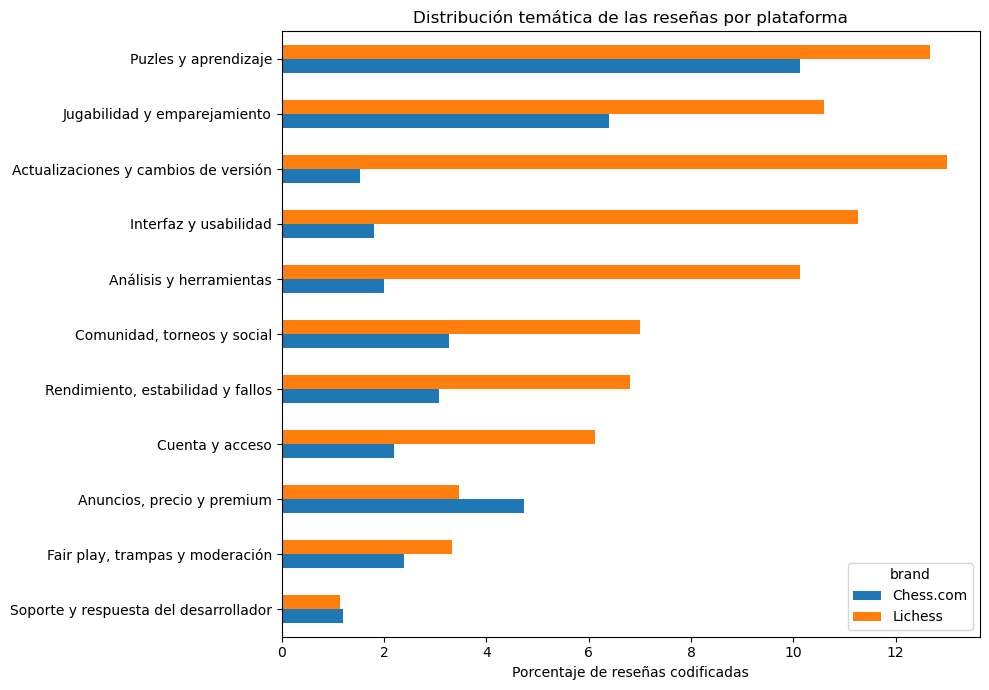

In [29]:
# 10. Gráfico principal: distribución temática comparable limpia
# -------------------------

chart_data_clean = theme_summary_df_clean[
    theme_summary_df_clean["dataset_type"] == "comparable_final_3000"
].copy()

theme_order_clean = (
    chart_data_clean.groupby("theme_es")["share_of_reviews"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

pivot_share_clean = (
    chart_data_clean.pivot(index="theme_es", columns="brand", values="share_of_reviews")
    .reindex(theme_order_clean)
) * 100

ax = pivot_share_clean.plot(kind="barh", figsize=(10, 7))
ax.set_title("Distribución temática de las reseñas por plataforma")
ax.set_xlabel("Porcentaje de reseñas codificadas")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("chart_theme_share_by_platform_comparable_clean.png", dpi=200, bbox_inches="tight")
plt.show()


# -------------------------


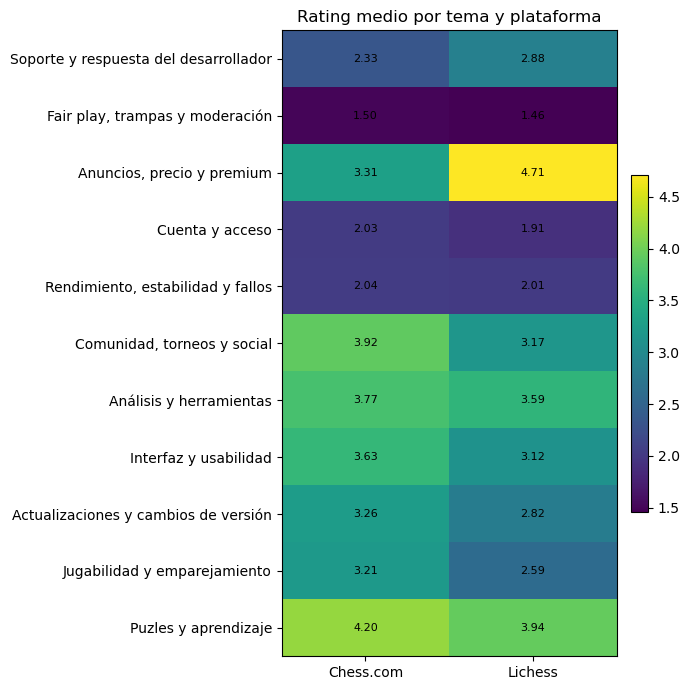

In [30]:
# 11. Heatmap: rating medio por tema y plataforma
# -------------------------

pivot_rating_clean = (
    chart_data_clean.pivot(index="theme_es", columns="brand", values="average_rating")
    .reindex(theme_order_clean)
)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(pivot_rating_clean.values, aspect="auto")

ax.set_title("Rating medio por tema y plataforma")
ax.set_xticks(range(len(pivot_rating_clean.columns)))
ax.set_xticklabels(pivot_rating_clean.columns)
ax.set_yticks(range(len(pivot_rating_clean.index)))
ax.set_yticklabels(pivot_rating_clean.index)

for i in range(pivot_rating_clean.shape[0]):
    for j in range(pivot_rating_clean.shape[1]):
        value = pivot_rating_clean.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("chart_theme_avg_rating_heatmap_comparable_clean.png", dpi=200, bbox_inches="tight")
plt.show()


# -------------------------


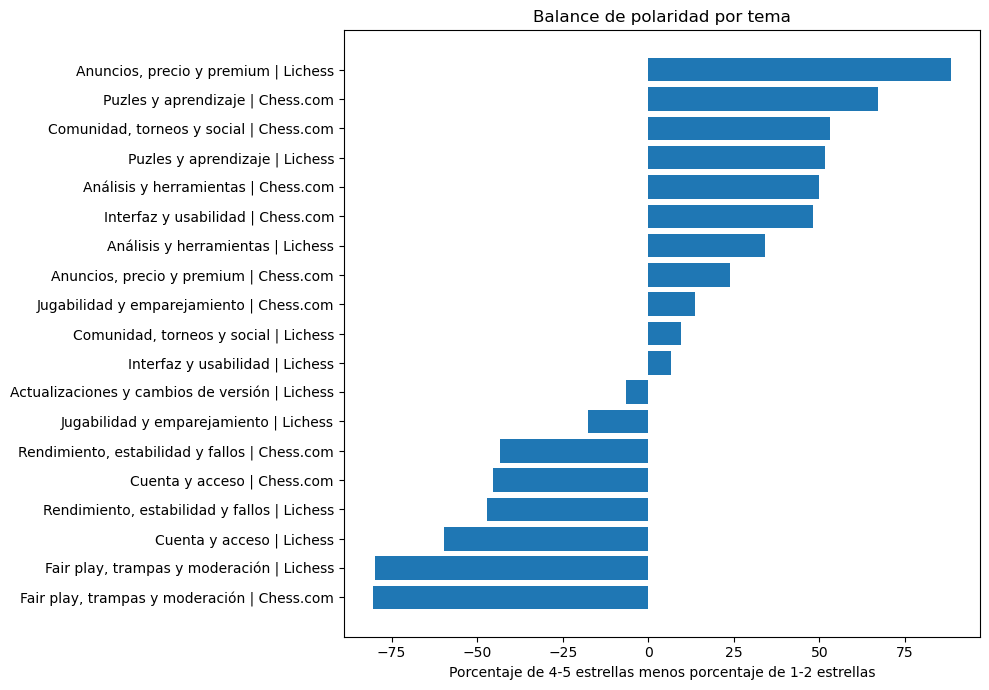

In [31]:
# 12. Polarización: solo temas con tamaño mínimo
# -------------------------

min_n_for_polarization = 25

polar_data = chart_data_clean.copy()
polar_data = polar_data[polar_data["n_reviews"] >= min_n_for_polarization].copy()

polar_data["balance_polaridad"] = (
    polar_data["pct_4_5_star"] - polar_data["pct_1_2_star"]
)

polar_data["label"] = polar_data["theme_es"] + " | " + polar_data["brand"]
polar_data = polar_data.sort_values("balance_polaridad")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(polar_data["label"], polar_data["balance_polaridad"] * 100)
ax.set_title("Balance de polaridad por tema")
ax.set_xlabel("Porcentaje de 4-5 estrellas menos porcentaje de 1-2 estrellas")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("chart_theme_polarization_comparable_min25.png", dpi=200, bbox_inches="tight")
plt.show()


# -------------------------


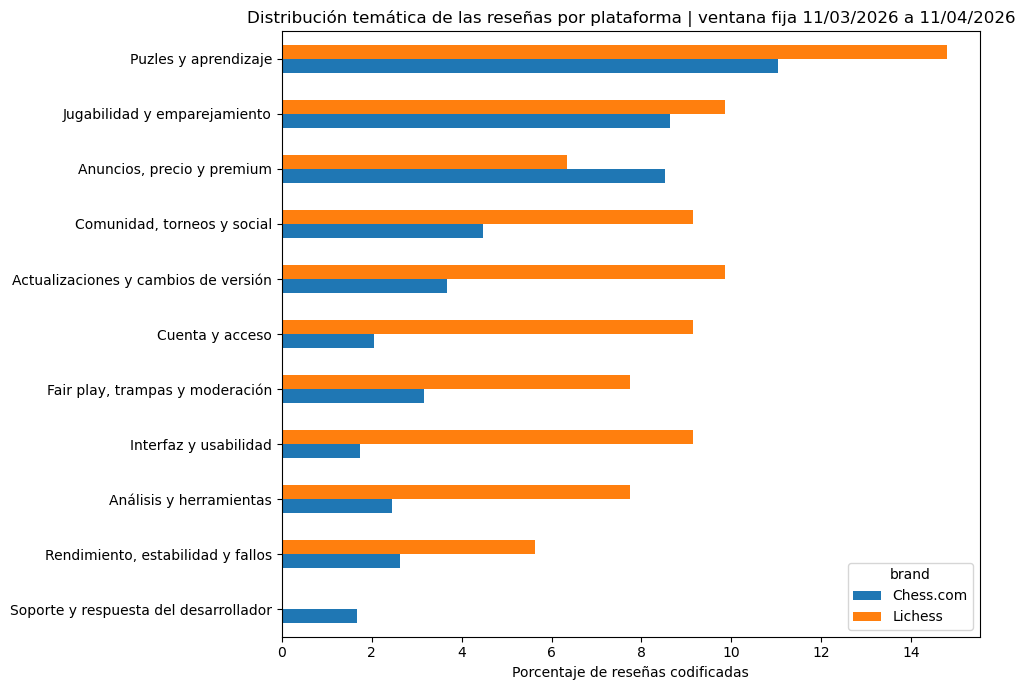

In [32]:
# 13. Gráfico fixed window como contraste metodológico
# -------------------------

chart_data_fixed_clean = theme_summary_df_clean[
    theme_summary_df_clean["dataset_type"] == "fixed_window_2026-03-11_to_2026-04-11"
].copy()

theme_order_fixed = (
    chart_data_fixed_clean.groupby("theme_es")["share_of_reviews"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

pivot_share_fixed_clean = (
    chart_data_fixed_clean.pivot(index="theme_es", columns="brand", values="share_of_reviews")
    .reindex(theme_order_fixed)
) * 100

ax = pivot_share_fixed_clean.plot(kind="barh", figsize=(10, 7))
ax.set_title("Distribución temática de las reseñas por plataforma | ventana fija 11/03/2026 a 11/04/2026")
ax.set_xlabel("Porcentaje de reseñas codificadas")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("chart_theme_share_by_platform_fixed_window_clean.png", dpi=200, bbox_inches="tight")
plt.show()


# -------------------------


In [33]:
# 14. Nota metodológica breve para el TFG
# -------------------------

method_note = """
La codificación temática de las reseñas de Google Play se aplicó mediante un sistema explícito de reglas y diccionarios de términos. La lógica es multietiqueta, de modo que una misma reseña puede activar varios temas si menciona asuntos distintos. Por ello, los porcentajes temáticos dentro de cada plataforma no se interpretan como particiones excluyentes y no tienen por qué sumar 100%.

Para la comparación principal entre plataformas se utilizó la muestra comparable final de 3.000 reseñas, equilibrada entre Lichess y Chess.com. De forma complementaria, se elaboró una segunda salida temática para la ventana fija 11/03/2026 a 11/04/2026 con el fin de alinearla temporalmente con Brand24. Esta segunda salida se usa como contraste metodológico y no como base principal de comparación simétrica, dado que el volumen disponible por plataforma es muy desigual.
"""

print(method_note)



La codificación temática de las reseñas de Google Play se aplicó mediante un sistema explícito de reglas y diccionarios de términos. La lógica es multietiqueta, de modo que una misma reseña puede activar varios temas si menciona asuntos distintos. Por ello, los porcentajes temáticos dentro de cada plataforma no se interpretan como particiones excluyentes y no tienen por qué sumar 100%.

Para la comparación principal entre plataformas se utilizó la muestra comparable final de 3.000 reseñas, equilibrada entre Lichess y Chess.com. De forma complementaria, se elaboró una segunda salida temática para la ventana fija 11/03/2026 a 11/04/2026 con el fin de alinearla temporalmente con Brand24. Esta segunda salida se usa como contraste metodológico y no como base principal de comparación simétrica, dado que el volumen disponible por plataforma es muy desigual.

